<a href="https://colab.research.google.com/github/D-Barradas/RAPIDS_HPO/blob/main/notebooks/HPO_Skorch_RAPIDS_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Optimization (HPO) with Skorch, RAPIDS, and PyTorch on MNIST

This tutorial shows how to combine:
- PyTorch for model definition
- Skorch for sklearn-style training loops
- Optuna for hyperparameter optimization
- RAPIDS (cuDF, cuML, CuPy) for GPU-accelerated preprocessing

The notebook is designed to run in Google Colab with GPU enabled.

## 1. Install and Import Dependencies

Install all required packages. RAPIDS installation can vary depending on Colab CUDA version, so this notebook includes a graceful fallback if RAPIDS is unavailable.

In [1]:
# Core ML stack
!pip -q install skorch optuna optuna-integration[skorch] #scikit-learn matplotlib pandas

# PyTorch + torchvision (usually preinstalled in Colab, re-run for consistency)
#!pip -q install torch torchvision

# RAPIDS packages for CUDA 12 in Colab.
# If these fail due to environment constraints, the notebook will continue with CPU preprocessing.
#!pip -q install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12 cupy-cuda12x || true

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 9.4 MB/s eta 0:00:00


In [5]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import datasets, transforms

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import optuna
from optuna.integration import SkorchPruningCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 2. Check Runtime and RAPIDS Availability

This cell confirms whether CUDA is available and whether RAPIDS libraries were installed successfully.

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Using device:', device)

RAPIDS_AVAILABLE = True
try:
    import cudf
    import cuml
    import cupy as cp
    from cuml.preprocessing import StandardScaler as cuStandardScaler
    print('cuDF version:', cudf.__version__)
    print('cuML version:', cuml.__version__)
    print('CuPy version:', cp.__version__)
except Exception as e:
    RAPIDS_AVAILABLE = False
    cp = None
    print('RAPIDS not available. Falling back to sklearn preprocessing.')
    print('Details:', e)

Torch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
cuDF version: 26.02.01
cuML version: 26.02.000
CuPy version: 14.0.1


## 3. Load and Prepare MNIST

We load MNIST from torchvision, flatten images from 28x28 to 784 features, normalize pixel values, and build smaller stratified subsets for faster HPO in Colab.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

dir_path = '/content/drive/MyDrive/Accel_DS_RAPIDS/part4/data/'

print(f"Checking existence of directory: {dir_path}")
if os.path.exists(dir_path) and os.path.isdir(dir_path):
    print(f"The directory '{dir_path}' exists.")
else:
    print(f"Creating '{dir_path}'.")
    # Create data folder if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking existence of directory: /content/drive/MyDrive/Accel_DS_RAPIDS/part4/data/
The directory '/content/drive/MyDrive/Accel_DS_RAPIDS/part4/data/' exists.


In [7]:
transform = transforms.ToTensor()
train_set = datasets.MNIST(root=dir_path, train=True, download=True, transform=transform)
test_set = datasets.MNIST(root=dir_path, train=False, download=True, transform=transform)

X_train_full = train_set.data.numpy().reshape(-1, 28 * 28).astype(np.float32) / 255.0
y_train_full = train_set.targets.numpy().astype(np.int64)

X_test_full = test_set.data.numpy().reshape(-1, 28 * 28).astype(np.float32) / 255.0
y_test_full = test_set.targets.numpy().astype(np.int64)

# Keep the optimization loop practical for Colab runtime limits.
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=20000, stratify=y_train_full, random_state=SEED
)

X_test_small, _, y_test_small, _ = train_test_split(
    X_test_full, y_test_full,
    train_size=5000, stratify=y_test_full, random_state=SEED
)

print('Train subset:', X_train_small.shape, y_train_small.shape)
print('Test subset:', X_test_small.shape, y_test_small.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 519kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.6MB/s]


Train subset: (20000, 784) (20000,)
Test subset: (5000, 784) (5000,)


In [8]:
if RAPIDS_AVAILABLE:
    print('Using RAPIDS (cuML) StandardScaler on GPU...')
    scaler = cuStandardScaler(with_mean=True, with_std=True)

    X_train_gpu = cp.asarray(X_train_small)
    X_test_gpu = cp.asarray(X_test_small)

    X_train_small = cp.asnumpy(scaler.fit_transform(X_train_gpu)).astype(np.float32)
    X_test_small = cp.asnumpy(scaler.transform(X_test_gpu)).astype(np.float32)
else:
    print('Using sklearn StandardScaler on CPU...')
    scaler = StandardScaler()
    X_train_small = scaler.fit_transform(X_train_small).astype(np.float32)
    X_test_small = scaler.transform(X_test_small).astype(np.float32)

print('Data prepared for Skorch:', X_train_small.shape, X_test_small.shape)

Using RAPIDS (cuML) StandardScaler on GPU...
Data prepared for Skorch: (20000, 784) (5000, 784)


## 4. Define a Flexible PyTorch Model for Skorch

Skorch wraps this PyTorch module with an sklearn-like API, so it can be optimized with Optuna while keeping full PyTorch model flexibility.

In [9]:
class MNISTClassifier(nn.Module):
    def __init__(self, input_dim=784, hidden_units=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, hidden_units // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units // 2, 10)
        )

    def forward(self, X):
        return self.net(X)

## 5. Baseline Model (Before HPO)

Train one baseline configuration first. This gives a reference score to compare against Optuna-optimized settings.

In [10]:
baseline_net = NeuralNetClassifier(
    MNISTClassifier,
    module__hidden_units=256,
    module__dropout=0.3,
    max_epochs=8,
    lr=1e-3,
    batch_size=256,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    iterator_train__shuffle=True,
    train_split=ValidSplit(0.2, stratified=True),
    device=device,
    verbose=0
)

baseline_net.fit(X_train_small, y_train_small)
baseline_pred = baseline_net.predict(X_test_small)
baseline_acc = accuracy_score(y_test_small, baseline_pred)
print(f'Baseline test accuracy: {baseline_acc:.4f}')

Baseline test accuracy: 0.9570


## 6. Define the Optuna Objective

Each Optuna trial proposes a new hyperparameter set, trains the Skorch model, and returns validation accuracy. The pruning callback can stop weak trials early to save time.

In [11]:
def objective(trial):
    hidden_units = trial.suggest_int('hidden_units', 128, 512, step=64)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    max_epochs = trial.suggest_int('max_epochs', 5, 12)

    net = NeuralNetClassifier(
        MNISTClassifier,
        module__hidden_units=hidden_units,
        module__dropout=dropout,
        max_epochs=max_epochs,
        lr=lr,
        batch_size=batch_size,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        iterator_train__shuffle=True,
        train_split=ValidSplit(0.2, stratified=True),
        callbacks=[SkorchPruningCallback(trial, monitor='valid_acc')],
        device=device,
        verbose=0
    )

    net.fit(X_train_small, y_train_small)
    return net.history[-1, 'valid_acc']

## 7. Run Hyperparameter Optimization

This step launches the Optuna study. Adjust trial count and timeout based on your Colab session budget.

In [12]:
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='maximize', pruner=pruner)

study.optimize(objective, n_trials=20, timeout=1200)

print('Finished trials:', len(study.trials))
print('Best validation accuracy:', study.best_value)
print('Best parameters:')
for k, v in study.best_trial.params.items():
    print(f'  {k}: {v}')

[I 2026-07-23 10:19:12,144] A new study created in memory with name: no-name-dafbe8f8-bdb1-4ea1-a911-57eb30ba7005
[I 2026-07-23 10:19:20,153] Trial 0 finished with value: 0.9085 and parameters: {'hidden_units': 128, 'dropout': 0.1302988185778051, 'lr': 0.00013573913929572205, 'batch_size': 512, 'max_epochs': 12}. Best is trial 0 with value: 0.9085.
[I 2026-07-23 10:19:25,435] Trial 1 finished with value: 0.96 and parameters: {'hidden_units': 256, 'dropout': 0.17769573264766747, 'lr': 0.0006580533759279431, 'batch_size': 128, 'max_epochs': 9}. Best is trial 1 with value: 0.96.
[I 2026-07-23 10:19:27,029] Trial 2 finished with value: 0.9415 and parameters: {'hidden_units': 128, 'dropout': 0.16447241656255696, 'lr': 0.0007123814275392838, 'batch_size': 256, 'max_epochs': 6}. Best is trial 1 with value: 0.96.
[I 2026-07-23 10:19:28,400] Trial 3 finished with value: 0.958 and parameters: {'hidden_units': 384, 'dropout': 0.2961467533072889, 'lr': 0.0011727694423190708, 'batch_size': 512, 'ma

Finished trials: 20
Best validation accuracy: 0.96
Best parameters:
  hidden_units: 256
  dropout: 0.17769573264766747
  lr: 0.0006580533759279431
  batch_size: 128
  max_epochs: 9


## 8. Retrain with Best Hyperparameters and Evaluate on Test Data

After tuning, we retrain using the best hyperparameters and evaluate on the held-out MNIST test subset.

In [13]:
best_params = study.best_trial.params

best_net = NeuralNetClassifier(
    MNISTClassifier,
    module__hidden_units=best_params['hidden_units'],
    module__dropout=best_params['dropout'],
    max_epochs=best_params['max_epochs'],
    lr=best_params['lr'],
    batch_size=best_params['batch_size'],
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    iterator_train__shuffle=True,
    train_split=None,
    device=device,
    verbose=0
)

best_net.fit(X_train_small, y_train_small)
best_pred = best_net.predict(X_test_small)
best_acc = accuracy_score(y_test_small, best_pred)

print(f'Baseline test accuracy: {baseline_acc:.4f}')
print(f'Best HPO test accuracy: {best_acc:.4f}')
print('')
print(classification_report(y_test_small, best_pred))

Baseline test accuracy: 0.9570
Best HPO test accuracy: 0.9642

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       490
           1       0.98      0.99      0.98       567
           2       0.97      0.96      0.97       516
           3       0.96      0.97      0.97       505
           4       0.95      0.97      0.96       491
           5       0.95      0.96      0.96       446
           6       0.97      0.96      0.97       479
           7       0.95      0.98      0.97       514
           8       0.97      0.94      0.95       487
           9       0.96      0.93      0.95       505

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



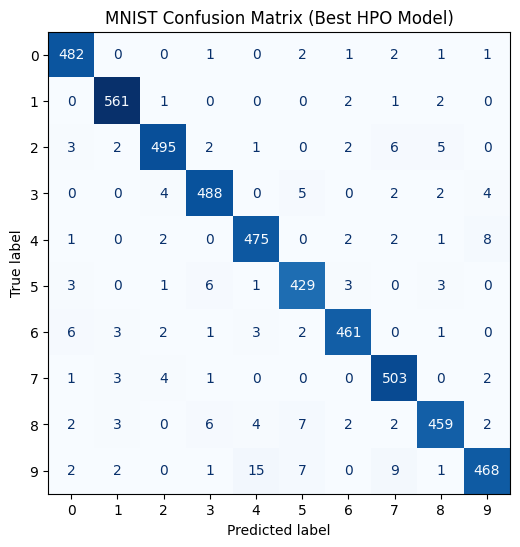

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test_small, best_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('MNIST Confusion Matrix (Best HPO Model)')
plt.show()

## 9. Visualize the Optimization Process

Optuna visualizations help explain search behavior and parameter importance for your final report or tutorial discussion.

In [15]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

## 10. Summary

In this notebook you:
- Built an MNIST classifier in PyTorch
- Trained it with Skorch using an sklearn-like interface
- Applied Optuna for HPO with pruning
- Used RAPIDS preprocessing when available on Colab GPU

Next improvements you can try:
- Expand the search space (optimizers, weight decay, scheduler)
- Use a larger train subset or full MNIST for final scoring
- Log studies to persistent storage and compare multiple runs